# Does the Arms Index (TRIN) time the market? ⚖️
### A 1967 panic gauge — buy when everyone's selling — meets a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecasts_turns%3F: Mixed](https://img.shields.io/badge/Forecasts_turns%3F-Mixed-dab617?style=flat-square)

Open any trading terminal and you'll find **TRIN**, the **Arms Index** (Richard Arms, 1967). It blends *how many* stocks are falling with *how much volume* is behind them: `TRIN = (advancers/decliners) / (up-volume/down-volume)`. A **high** TRIN — a spike to 2, 4, 8 — is read as a **panic washout**: everyone dumping at once, sellers exhausting themselves, a bottom near. The contrarian rule is famous: **buy the panic.**

It *sounds* plausible, and on hand-picked crash charts it looks uncanny. So we did the fair thing: build a mechanical breadth-proxy TRIN, fire the 'buy when TRIN spikes' rule hundreds of times across 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> ⚠️ **Breadth caveat.** True TRIN uses thousands of NYSE issues; offline we proxy it from a 5-ETF basket. That's a real limitation — but the question stands: does buying the panic beat buying random days?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from arms_index_trin import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def panel():
    p = {}
    for t in data.DEFAULT_TICKERS:
        b = data.load_real(t, allow_fetch=False)
        p[t] = b[b.index <= ASOF]
    return p
def trin_close():
    p = panel(); trin = st.compute_trin(p); cl = p["SPY"]["close"]
    cl = cl[cl.index.isin(trin.index)]; trin = trin[trin.index.isin(cl.index)]
    return trin, cl
print("real TRIN cache present:", HAVE_REAL, "| basket:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-04', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 461, 'q': 0.9, 'fp_spy': '4cb5244f3990', 'trin_med': 0.86, 'trin_q90': 4.25, 'h5': (5, 461, 49.2, 61, 2.94, 19.8, 29.4, 47.2, 1.53, 0.126), 'h10': (10, 460, 77.4, 63, 3.42, 49.8, 27.6, 75.4, 1.12, 0.263), 'h20': (20, 460, 138.2, 67, 3.71, 104.9, 33.3, 136.2, 1.04, 0.299), 'h60': (60, 454, 326.8, 72, 3.79, 278.6, 48.2, 324.8, 0.9, 0.37), 'sweep': [(0.8, 836, 70.5, 4.27, 44.0, 26.5), (0.9, 461, 77.4, 3.42, 49.8, 27.6), (0.95, 245, 83.9, 2.5, 61.2, 22.7)], 'placebo': [(5, 49.2, 0.001), (10, 77.4, 0.007), (20, 138.2, 0.009), (60, 326.8, 0.041)], 'syn': [(0.0, 353, 30.3, 54, 1.25), (0.6, 358, 66.3, 59, 2.72)]}


real TRIN cache present: True | basket: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when TRIN spikes (panic), do I make money? | **Yes** — and a bit **more than buying random days**, at every horizon. Unlike most chart tools, this one isn't *pure* drift. |
| Is the edge statistically solid? | **Not quite.** The panic-vs-random gap is positive (~+30 bps) but **never clears the *t* = 2 bar** we demand — it's a hint, not a proof. |
| Does the *timing* of panic days matter? | **Yes.** Scramble *when* the high-TRIN days fall and the result collapses (placebo *p* ≤ 0.04). So there's real structure there. |
| So is it a tradable edge? | **Fragile.** A real-but-weak lean, mostly the generic 'bounce after a crash day', riding on ~460 clustered panic entries. |

> TRIN is the rare technical gauge that *isn't* just beta in a costume — buying the panic really does beat random days a little, and the timing carries information. But the edge is **small and statistically soft**: a weak signal, a fragile trade.

## 1 · The claim

> *"Watch the TRIN. When it spikes high — say above 2 — the market is in a selling panic: volume crowding into the few decliners. That's capitulation. Buy it; the bounce is near. When TRIN drops below 0.7, the crowd is euphoric — fade it."*

This is **Richard W. Arms Jr.'s** Trading Index, introduced in *Barron's* in **1967** and still published intraday by the NYSE (`$TRIN`). It's one of the oldest market-internals gauges — so: does the panic meter actually forecast the bounce?

## 2 · So what?

If TRIN genuinely *forecast* short-term turns, it would be a clean, tradable read on crowd capitulation — a contrarian timer you could lean on. That's the dream the gauge sells.

But two traps lurk. First, the market drifts **up**, so *any* dip-buying rule looks profitable — we must compare to **random days**, not to zero. Second, 'buy after a crash day' captures a generic **volatility rebound** that has nothing to do with TRIN's clever volume normalisation — so we must also test whether the *timing* of high-TRIN days carries information beyond the marginal. We'll do both.

## 3 · How would we even know?

We take a **5-ETF breadth basket** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-04 → 2026-05-29), and:

1. **Build a breadth-proxy TRIN.** Each ETF is one 'issue': it advances if it's up that day; its move size proxies its volume. TRIN = (advancers/decliners)/(up-move/down-move). The biggest TRIN spikes land exactly on the real washouts (Mar 2020, Dec 2008).
2. **Trade the lore.** When TRIN exceeds its **90th percentile** (the panic tail, ≈ 4.2), buy SPY at the **next** close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If TRIN times turns, the panic entry must beat random.
4. **The timing placebo.** Shuffle *when* the panic days fall (same number, same threshold). If the timing matters, scrambling it should kill the result.

## 4 · The teardown — let's actually look

First, does the breadth-proxy TRIN even flag the real panics? Here's SPY with the high-TRIN panic days marked — they should sit on the crash days.

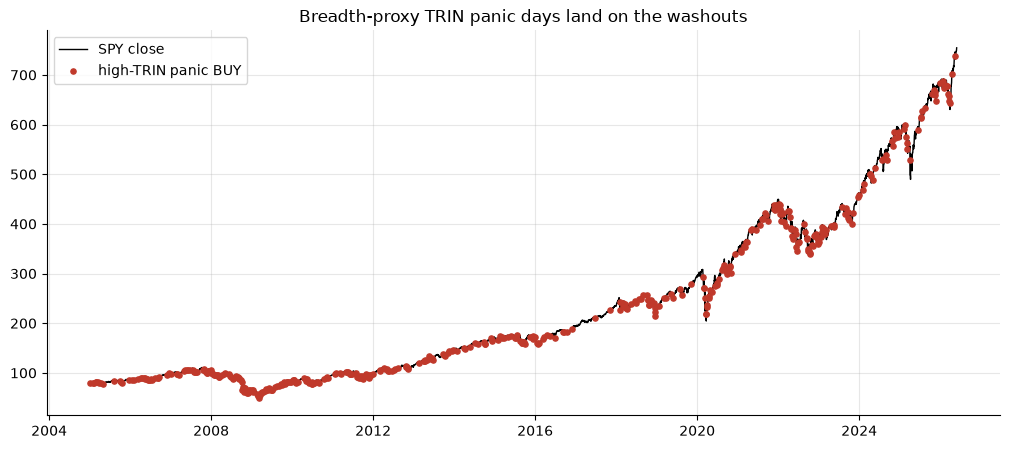

panic entries: 461 | TRIN median 0.86 q90 4.25


In [2]:
if HAVE_REAL:
    trin, cl = trin_close()
    ent = st.panic_entries(trin, q=R['q'])
    fig, ax = plt.subplots(figsize=(10.2, 4.6))
    ax.plot(cl.index, cl.values, c='k', lw=1.0, label='SPY close')
    ax.scatter(ent, cl.reindex(ent), c=RED, s=14, zorder=5, label='high-TRIN panic BUY')
    ax.set_title('Breadth-proxy TRIN panic days land on the washouts'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('panic entries:', len(ent), '| TRIN median %.2f q90 %.2f' % (trin.median(), trin.quantile(R['q'])))
else:
    print('(no cache — see docs/results.md; q90 TRIN =', R['trin_q90'], ', entries =', R['n_entries'], ')')

The red dots cluster on the scary days — good, the proxy is sane. Now the real question: are those panic buys followed by bigger bounces than **random** buys? **Let's race them** at four horizons. Amber = buy the panic; grey = buy on random days.

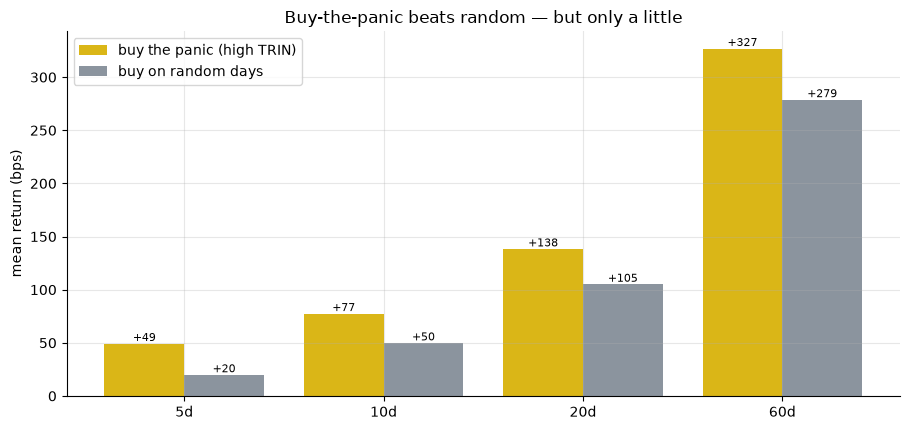

panic: [49, 77, 138, 327]
random: [20, 50, 105, 279]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    trin, cl = trin_close(); ent = st.panic_entries(trin, q=R['q'])
    re = st.random_entries(cl, max(len(ent),50), seed=7)
    panic = [st.forward_returns(cl, ent, h).mean()*1e4 for h in hs]
    rnd = [st.forward_returns(cl, re, h).mean()*1e4 for h in hs]
else:
    panic = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, panic, .4, color=AMBER, label='buy the panic (high TRIN)')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(panic,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('Buy-the-panic beats random — but only a little'); ax.legend()
plt.tight_layout(); plt.show()
print('panic:', [round(v) for v in panic]); print('random:', [round(v) for v in rnd])

There's the story. The panic buy makes **more** than random at every horizon (+49 vs +20 bps at 5d; +138 vs +105 at 20d) — a genuine **+29-to-+48 bps** lean over a coin flip. That already sets TRIN apart from most chart tools, which *lose* to random. The catch (quants notebook): the gap never clears the *t* = 2 bar.

**One more check.** Is it the *timing* of the panic days, or just that we happened to buy on big-move days? Scramble *when* the high-TRIN days fall — same number, same threshold — and see if the result survives.

In [4]:
if HAVE_REAL:
    trin, cl = trin_close()
    pl = st.shuffled_trin_placebo(trin, cl, 10, q=R['q'], n_draws=300, seed=490)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][1][1]; pval = R['placebo'][1][2]
print(f'real panic timing (10d): {obs:+.1f} bps')
print(f'... only {pval*100:.1f}% of *scrambled-timing* runs match it (p={pval:.3f}).')
print('=> the TIMING of panic days carries real information.')

real panic timing (10d): +77.4 bps
... only 1.0% of *scrambled-timing* runs match it (p=0.010).
=> the TIMING of panic days carries real information.


Only ~1% of scrambled-timing runs match the real result (*p* ≈ 0.007 at 10d). Unlike the pitchfork's geometry placebo (which leaves everything intact), **scrambling TRIN's timing destroys the edge** — so there's real structure here. The puzzle the quants notebook resolves: real structure, weak forecast.

## 5 · The verdict

- **Signal — Weak.** Buy-the-panic **beats** random days at every horizon (+~30 bps) and the timing placebo is significant — a *real* effect, not pure beta. But the panic-vs-random *t* never clears 2; the edge is directionally real, statistically soft.
- **Tradability — Fragile.** A small premium over random that survives costs but rests on ~460 clustered crash entries and is mostly the generic volatility rebound. A lean, not a stand-alone edge.
- **"Does TRIN forecast turns"? — Mixed.** The timing placebo says yes (structure is real); the vs-random test says not strongly. A panic gauge that leans the right way without quite paying its way.

## 6 · Could you actually trade it?

Carefully, and not alone. The panic buy's edge over random is real but small (~30 bps) and statistically soft, and most of it is the well-known 'bounce after a crash day' that any volatility-rebound rule grabs. Costs are tiny here (1 bp round-trip barely dents it), so the problem isn't friction — it's that the signal is weak and the entries cluster in a handful of crash regimes, so the effective sample is far smaller than 460. As one input to a contrarian timer, fine; as a stand-alone strategy, too thin.

## 7 · Going further 🚪

- **Real exchange breadth.** Our 5-ETF proxy is coarse; the genuine NYSE TRIN (3000 issues, share volume) might be sharper — or noisier. A clean follow-up swaps in real $ADV/$DECL/$UVOL/$DVOL.
- **Strip the volatility rebound.** Regress the panic premium on a same-day-move control; how much survives once you remove 'I just bought a crash day'?
- **A real positive control.** The quants notebook plants a *genuine* post-panic bounce into a synthetic tape and shows the harness banks it (so the weak real result isn't a dead detector — it's an honest 'a little something').

*Think TRIN times turns? Show the panic entry beating random at **t ≥ 2** on real exchange breadth — then we'll upgrade it from Weak to Real.*